In [31]:
# =========================
# SALES FORECASTING PROJECT
# USING SUPERSTORE DATASET
# =========================

# Step 1: Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [32]:
# Step 2: Load Dataset
# Replace file name with your actual file

df = pd.read_csv(r"C:\Users\91928\Downloads\Sample - Superstore - Copy.csv", encoding="latin1")

In [33]:
# Step 3: View Dataset

print("First 5 Rows:")
print(df.head())

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

First 5 Rows:
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0     

In [34]:
# Step 4: Data Cleaning

df.dropna(inplace=True)

In [35]:
# Step 5: Convert Order Date

df['Order Date'] = pd.to_datetime(df['Order Date'])


In [36]:
# Step 6: Feature Engineering

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Day'] = df['Order Date'].dt.day


In [37]:
# Step 7: Select Features and Target

X = df[['Year', 'Month', 'Day', 'Quantity', 'Discount', 'Profit']]
y = df['Sales']
 

In [38]:
# Step 8: Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [39]:
# Step 9: Model Training

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [40]:
# Step 10: Prediction

y_pred = model.predict(X_test)


In [41]:
# Step 11: Model Evaluation

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nModel Performance")
print("MAE :", mae)
print("RMSE :", rmse)
print("R2 Score :", r2)



Model Performance
MAE : 113.19496545522759
RMSE : 523.3798781670915
R2 Score : 0.5362673351879994


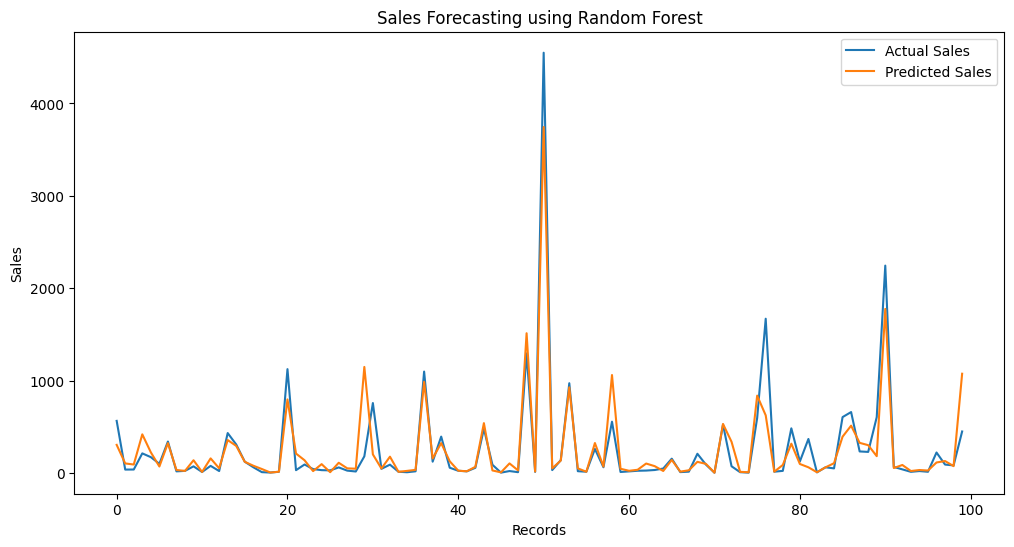

In [42]:
# Step 12: Visualization

plt.figure(figsize=(12,6))

plt.plot(y_test.values[:100], label='Actual Sales')
plt.plot(y_pred[:100], label='Predicted Sales')

plt.title("Sales Forecasting using Random Forest")
plt.xlabel("Records")
plt.ylabel("Sales")
plt.legend()

plt.show()

In [43]:
# feature

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

print(importance.sort_values(by='Importance', ascending=False))

    Feature  Importance
5    Profit    0.872845
4  Discount    0.042175
2       Day    0.027695
3  Quantity    0.026666
1     Month    0.017902
0      Year    0.012718


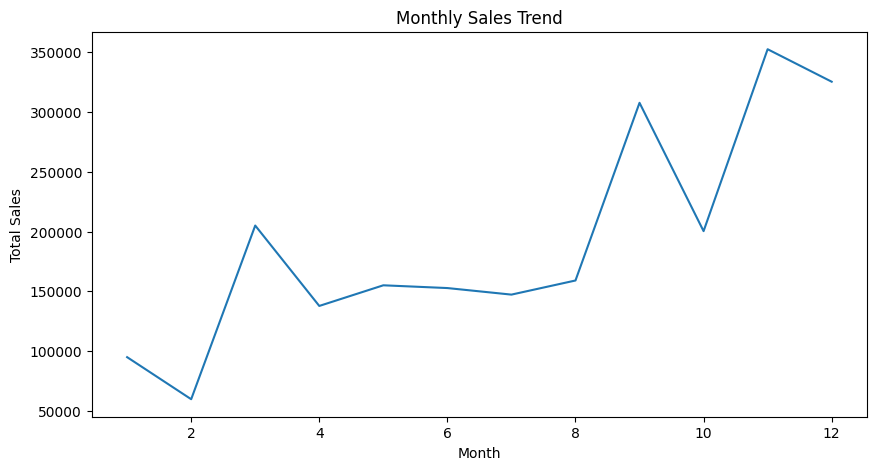

In [44]:
# Monthly Sales Trend Graph

monthly_sales = df.groupby('Month')['Sales'].sum()

monthly_sales.plot(figsize=(10,5), title="Monthly Sales Trend")

plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

In [45]:
# Save Model
import joblib

joblib.dump(model, "sales_forecasting_model.pkl")
print("Model Saved Successfully")

Model Saved Successfully


In [46]:
loaded_model = joblib.load("sales_forecasting_model.pkl")

print("Model Loaded Successfully")

Model Loaded Successfully


In [48]:
# New Data par prediction

new_data = pd.DataFrame({
    'Year': [2024],
    'Month': [5],
    'Day': [15],
    'Quantity': [3],
    'Discount': [0.2],
    'Profit': [150]
})

prediction = loaded_model.predict(new_data)

print("Predicted Sales:", prediction)

Predicted Sales: [529.81031]
